# S-parameter Simulations

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


(1000, 2, 1)


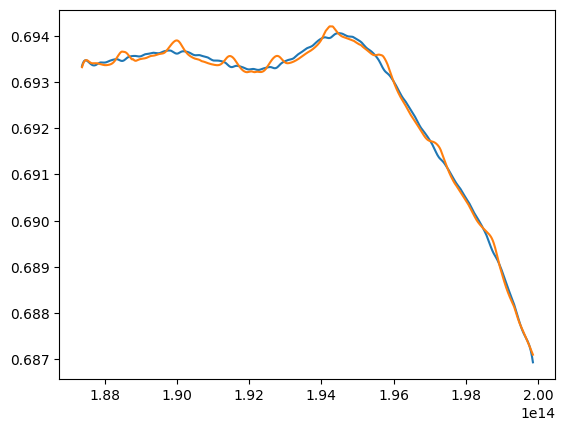

In [1]:
from simphony.time_domain.vector_fitting.z_domain import vector_fitting_discrete, state_space_discrete, pole_residue_response_discrete, optimize_order_vector_fitting_discrete
from simphony.libraries.siepic import y_branch
from simphony.utils import dict_to_rect_matrix, dict_to_matrix
import numpy as np
from scipy.constants import c
import matplotlib.pyplot as plt

wl = 1e-6*np.linspace(1.5, 1.6, 1000)
f = c/wl
lam0 = 1e-6*1.55
f_c = c/lam0
f_s = 1e14
dt = 1/f_s

# H = dict_to_matrix(y_branch(wl*1e6))
H = dict_to_rect_matrix(y_branch(wl*1e6), input_ports=["port_1"], output_ports=["port_2", "port_3"])
print(H.shape)


poles, residues, feedthrough, error = vector_fitting_discrete(50, H, f, f_c, f_s)
A, B, C, D = state_space_discrete(poles, residues, feedthrough)

plt.plot(f, np.abs(H[:, 0, 1]))
plt.plot(f, np.abs(pole_residue_response_discrete(f, f_c, f_s, poles, residues, feedthrough)[:, 0, 1]))

In [2]:
poles, residues, feedthrough, error = vector_fitting_discrete(25, H, f, f_c, f_s)

In [3]:
res =optimize_order_vector_fitting_discrete(2, 100, H, f, f_c, f_s)

In [4]:
res = optimize_order_vector_fitting_discrete(2, 100, H, f, f_c, f_s)

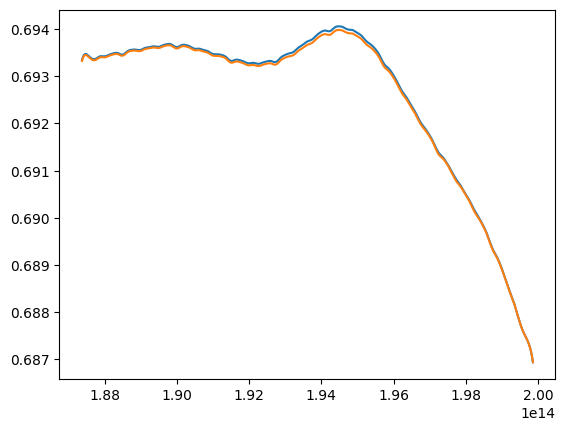

In [5]:
import matplotlib.pyplot as plt
plt.plot(f, np.abs(H[:, 0, 1]))
plt.plot(f, np.abs(H[:, 1, 0]))

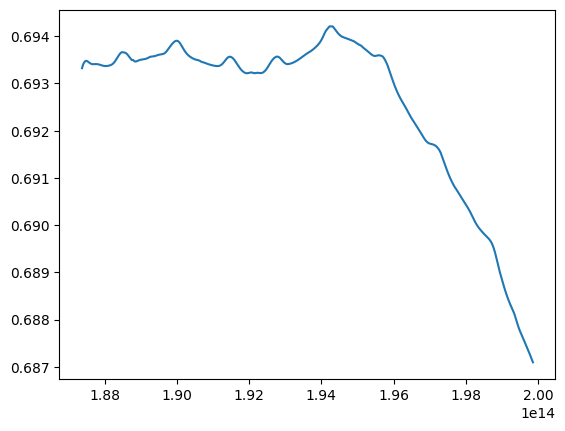

(100, 1)


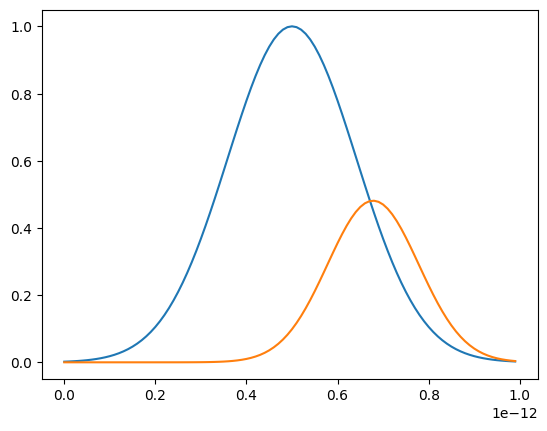

In [6]:
from simphony.time_domain.vector_fitting.z_domain import state_space_response_discrete, state_space_frequency_response_discrete
from simphony.time_domain.utils import gaussian_pulse
import matplotlib.pyplot as plt


H_hat = state_space_frequency_response_discrete(A, B, C, D, f, f_c, dt=dt)
# print(H_hat[:, 0, 1])
plt.plot(f, np.abs(H_hat[:, 0, 1]))
plt.show()

t = np.arange(0, 1e-12, dt)
u = np.zeros((len(t), D.shape[1]))
u[:, 0] = gaussian_pulse(t, 0.5e-12, 0.2e-12)
print(u.shape)
y, _ = state_space_response_discrete(A, B, C, D, u)
plt.plot(t, u)
plt.plot(t, np.abs(y[:, 2])**2)

In [7]:
y.shape

(100, 2)

In [8]:
u.shape

(100, 1)

In [9]:
from simphony.libraries.ideal.modulators import DirectedOpticalModulator
from simphony.libraries.ideal.sources import VoltageSource, CWLaser
from simphony.libraries.ideal.electrical_circuits import VoltageFollower
from simphony.libraries.ideal.s_parameters import optical_s_parameter
from simphony.libraries.siepic import y_branch, waveguide

import sax
import numpy as np

instances = {
    "splitter": "y_branch",
    "combiner": "y_branch",
    "wg1": "waveguide",
    "wg2": "waveguide",
    "mod1": "modulator",
    "mod2": "modulator",
    "vs1": "voltage_source",
    "vf1": "voltage_follower",
    "vs2": "voltage_source",
    "laser": "cw_laser",
}
connections = {
    "laser,o0": "splitter,port_1",
    "splitter,port_2": "wg1,o0",
    # "wg1,o1": "combiner,port_2",
    "wg1,o1": "mod1,o0",
    "mod1,o1": "combiner,port_2",
    "splitter,port_3": "wg2,o0",
    # "wg2,o1": "combiner,port_3",
    "wg2,o1": "mod2,o0",
    "mod2,o1": "combiner,port_3",
    "vs1,e0": "vf1,e0",
    "vf1,e1": "mod1,e0",
    "vs2,e0": "mod2,e0"
}
ports = {
}

netlist = {
    "instances": instances,
    "connections": connections,
    "ports": ports,
}

models = {
    "y_branch": y_branch,
    "waveguide": waveguide,
    "modulator": DirectedOpticalModulator,
    "voltage_source": VoltageSource,
    "voltage_follower": VoltageFollower,
    "cw_laser": CWLaser,
}

ckt_settings = {
    "splitter": {},
    "combiner": {},
    "wg1": {"length":10.0},
    "wg2": {"length":30.0},
    "mod1": {
        "phase_coefficients": np.array([0.0, 0.0, np.pi/2, 0]),
        # "phase_coefficients": np.array([0.0, 0.0, 0.0, 0])
    },
    "mod2": {},
    "vs1": {
        "steady_state_voltage": 1.0,
    },
    "vs2": {
        "steady_state_voltage": 0.0,
    },
}

In [10]:
from simphony.circuit.circuit import Circuit
from simphony.simulation.block_mode import BlockModeSimulation, BlockModeSimulationParameters
# from simphony.simulation.block_mode import BlockModeSimulationParameters

mzi_circuit = Circuit(netlist, models)
mzi_circuit.display()
# mzi_circuit.instantiate(ckt_settings, simulation_parameters)

/home/m1400073/finish_project/simphony/.venv/lib/python3.12/site-packages/sax/utils.py:80: UserWarning: Could not validate netlist for 'top_level'. This netlist will be ignored.
  return func(*args, **kwargs)


dst: splitter,port_1
dst_directionality: bidirectional
dst: wg1,o0
dst_directionality: bidirectional
dst: mod1,o0
dst_directionality: input
dst: combiner,port_2
dst_directionality: bidirectional
dst: wg2,o0
dst_directionality: bidirectional
dst: mod2,o0
dst_directionality: input
dst: combiner,port_3
dst_directionality: bidirectional
dst: vf1,e0
dst_directionality: input
dst: mod1,e0
dst_directionality: input
dst: mod2,e0
dst_directionality: input


Sigma(nx.MultiDiGraph with 10 nodes and 12 edges)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from simphony.signal.block_mode import BlockModeOpticalSignal, BlockModeElectricalSignal
from simphony.simulation.sample_mode import SampleModeSimulation

simulation_parameters = BlockModeSimulationParameters(mode_identifiers=("TE",))
block_mode_simulation = BlockModeSimulation(mzi_circuit, ckt_settings, simulation_parameters)
sim_result = block_mode_simulation.run()

/home/m1400073/finish_project/simphony/.venv/lib/python3.12/site-packages/sax/utils.py:80: UserWarning: Could not validate netlist for 'top_level'. This netlist will be ignored.
  return func(*args, **kwargs)


22


In [12]:
print(sim_result.component_outputs.keys())

dict_keys(['vs1', 'vs2', 'laser', 'vf1', 'sparameter_group0~o0_demux', 'sparameter_group0~o0_TE_converter_in', 'sparameter_group0~splitter_state_space', 'sparameter_group0~wg1_state_space', 'sparameter_group0~wg2_state_space', 'sparameter_group0~o2_TE_converter_out', 'sparameter_group0~o1_TE_converter_out', 'sparameter_group0~o2_mux', 'sparameter_group0~o1_mux', 'mod1', 'mod2', 'sparameter_group1~o0_demux', 'sparameter_group1~o2_demux', 'sparameter_group1~o0_TE_converter_in', 'sparameter_group1~o2_TE_converter_in', 'sparameter_group1~combiner_state_space', 'sparameter_group1~o1_TE_converter_out', 'sparameter_group1~o1_mux'])


/home/m1400073/finish_project/simphony/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/m1400073/finish_project/simphony/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


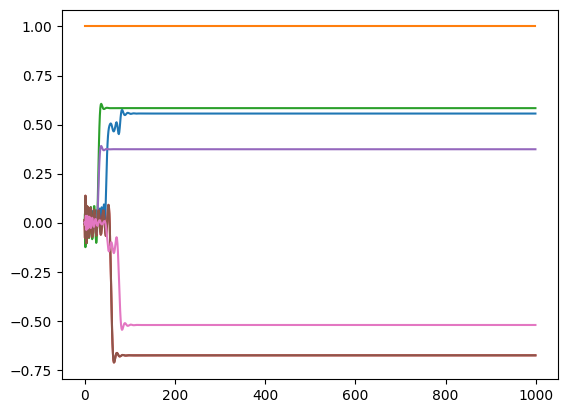

In [13]:
# TODO: Make simulation result map the outputs from the PCELL instance names 
plt.plot(np.abs(sim_result.component_outputs['sparameter_group1~o1_TE_converter_out']['out'].amplitude[:, 0, 0]))
for k in sim_result.component_outputs:
    if "out" in sim_result.component_outputs[k]:
        plt.plot(sim_result.component_outputs[k]["out"].amplitude[:, 0, 0])
 

In [ ]:
plt.plot(wl, np.abs(s_params_1d))

# Signal Flow Simulations

In [ ]:
from simphony.libraries.ideal.s_parameters import optical_s_parameter
from simphony.libraries.siepic import y_branch
import sax
import jax.numpy as jnp

from simphony.libraries.ideal.digital_filters import discrete_state_space
from simphony.simulation.simulation import SimulationMode


# state_space_model = discrete_state_space(2, 2)
def coupler():
    return {
        ("in0@TE", "out0@TE"): 0.45**0.5,
        ("in0@TE", "out1@TE"): 1j * 0.45**0.5,
        ("in1@TE", "out0@TE"): 1j * 0.45**0.5,
        ("in1@TE", "out1@TE"): 0.45**0.5,
        ("in0@TM", "out0@TM"): 0.45**0.5,
        ("in0@TM", "out1@TM"): 1j * 0.45**0.5,
        # ("in1@TM", "out0@TM"): 1j * 0.45**0.5,
        # ("in1@TM", "out1@TM"): 0.45**0.5,
        ("in0@TE", "out0@TM"): 0.01**0.5,
        ("in0@TE", "out1@TM"): 1j * 0.01**0.5,
        ("in1@TE", "out0@TM"): 1j * 0.01**0.5,
        ("in1@TE", "out1@TM"): 0.01**0.5,
        ("in0@TM", "out0@TE"): 0.01**0.5,
        ("in0@TM", "out1@TE"): 1j * 0.01**0.5,
        # ("in1@TM", "out0@TE"): 1j * 0.01**0.5,
        # ("in1@TM", "out1@TE"): 0.01**0.5,
    }

N = 4

A = jnp.eye(N, k=-1)
B = jnp.zeros((N, 1)).at[0, 0].set(1.0)

C = jnp.array([[0.5, 0.3, 0.1, 0.05]])
D = jnp.array([[0.2]])

# state_space_model(A, B, C, D)
# pcell = optical_s_parameter(coupler)
port_directionality = {
    'port_1': 'input', 
    'port_2': 'output', 
    'port_3': 'input'
}
pcell = optical_s_parameter(y_branch, port_directionality=port_directionality)
pcell(simulation_mode=SimulationMode.BLOCK_MODE)


In [ ]:
from simphony.libraries.ideal.photonic_circuits import mzi_lattice_filter

mzi_lattice_filter1 = mzi_lattice_filter()
mzi_lattice_filter1(None)

In [ ]:
def outer(a, b={}):
    class Inner:
        def __init__(self, c=3):
            print(a, b, c)
    return Inner

X = outer(1)
obj = X()  # prints: 1 2 3


In [ ]:
from simphony.libraries.ideal.s_parameters import optical_s_parameter
import sax
import jax.numpy as jnp

def waveguide(wl=1.55, wl0=1.55, neff=2.34, ng=3.4, length=10.0, loss=0.0):
    """A simple straight waveguide model

    Args:
        wl: wavelength
        neff: waveguide effective index
        ng: waveguide group index (used for linear neff dispersion)
        wl0: center wavelength at which neff is defined
        length: [m] wavelength length
        loss: [dB/m] waveguide loss
    """
    dwl = wl - wl0
    dneff_dwl = (ng - neff) / wl0
    neff = neff - dwl * dneff_dwl
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase)
    sdict = sax.reciprocal(
        {
            ("in0@TE", "out0@TE"): 0.95 * transmission,  # 5% lost to cross-polarization
            ("in0@TE", "out0@TM"): 0.05 * transmission,  # 5% cross-polarization
            ("in0@TM", "out0@TM"): 0.85 * transmission,  # 10% worse tm->tm than te->te
            ("in0@TM", "out0@TE"): 0.05 * transmission,  # 5% cross-polarization
        }
    )
    return sdict

def coupler():
    return {
        ("in0@TE", "out0@TE"): 0.45**0.5,
        ("in0@TE", "out1@TE"): 1j * 0.45**0.5,
        ("in1@TE", "out0@TE"): 1j * 0.45**0.5,
        ("in1@TE", "out1@TE"): 0.45**0.5,
        ("in0@TM", "out0@TM"): 0.45**0.5,
        ("in0@TM", "out1@TM"): 1j * 0.45**0.5,
        # ("in1@TM", "out0@TM"): 1j * 0.45**0.5,
        # ("in1@TM", "out1@TM"): 0.45**0.5,
        ("in0@TE", "out0@TM"): 0.01**0.5,
        ("in0@TE", "out1@TM"): 1j * 0.01**0.5,
        ("in1@TE", "out0@TM"): 1j * 0.01**0.5,
        ("in1@TE", "out1@TM"): 0.01**0.5,
        ("in0@TM", "out0@TE"): 0.01**0.5,
        ("in0@TM", "out1@TE"): 1j * 0.01**0.5,
        # ("in1@TM", "out0@TE"): 1j * 0.01**0.5,
        # ("in1@TM", "out1@TE"): 0.01**0.5,
    }

mzi, _ = sax.circuit(
    netlist={
        "instances": {
            "lft": "coupler",  # single mode models will be automatically converted to multimode models without cross polarization.
            "top": {"component": "straight", "settings": {"length": 25.0}},
            "btm": {"component": "straight", "settings": {"length": 15.0}},
            "rgt": "coupler",  # single mode models will be automatically converted to multimode models without cross polarization.
        },
        "connections": {
            "lft,out0": "btm,in0",
            "btm,out0": "rgt,in0",
            "lft,out1": "top,in0",
            "top,out0": "rgt,in1",
        },
        "ports": {
            "in0": "lft,in0",
            "in1": "lft,in1",
            "out0": "rgt,out0",
            "out1": "rgt,out1",
        },
    },
    models={
        "coupler": coupler,
        "straight": waveguide,
    },
)

mzi()

In [ ]:



port_directionality = {
    'port_1': 'input', 
    # 'port_2': 'input', 
    'port_3': 'output'
}

optical_s_parameter(y_branch, port_directionality=port_directionality)

In [ ]:
sax.multimode(mzi)() == sax.multimode(mzi, modes=("TESTMODE", "TESTMODE2"))() 